 # TCR Scimilarity Annotation Scirpy Clonality Analysis

## Environment Configuration

In [7]:
import scanpy as sc
from matplotlib import pyplot as plt
import pandas as pd
from scimilarity.utils import lognorm_counts, align_dataset
from scimilarity import CellAnnotation
plt.rcParams["figure.figsize"] = [6, 4]

import warnings
sc.settings.figdir = '../figs/'
warnings.filterwarnings("ignore")

# Set model_path to the location of the uncompressed model
model_path = "./model_v1.1"
ca = CellAnnotation(model_path=model_path)

## Loading adata and running SCimilarity

In [8]:
# Set data_path to the location of the tutorial dataset
data_path = "../data/GEX_ECZ_lesional_samples_integrated_fixed.h5ad"
adams = sc.read(data_path)

In [9]:
adams.layers['counts']=adams.X.copy()

running scimilarity

In [12]:
import scanpy.external as sce
adams = align_dataset(adams, ca.gene_order)
adams = lognorm_counts(adams)
adams.obsm["X_scimilarity"] = ca.get_embeddings(adams.X)
sce.pp.harmony_integrate(adams, key='ind_id', basis='X_scimilarity')

# Use the harmonized embedding for downstream analysis:
sc.pp.neighbors(adams, use_rep="X_harmony")
sc.tl.umap(adams)


2025-09-26 18:15:54,438 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-26 18:15:55,751 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-26 18:15:55,777 - harmonypy - INFO - Iteration 1 of 10
2025-09-26 18:15:56,909 - harmonypy - INFO - Iteration 2 of 10
2025-09-26 18:15:57,418 - harmonypy - INFO - Iteration 3 of 10
2025-09-26 18:15:57,807 - harmonypy - INFO - Converged after 3 iterations


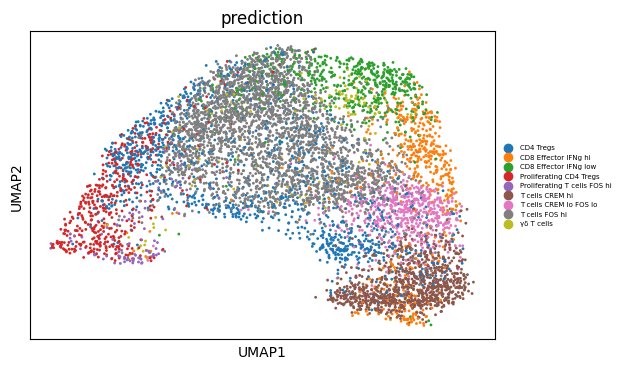

In [13]:
sc.pl.umap(adams, color=["prediction"], legend_fontsize=5,save='_gokcenannot.pdf')


restricting scimilarity for cleaner annotation

Get nearest neighbors finished in: 0.008914538224538167 min


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7256/7256 [00:00<00:00, 24642.17it/s]


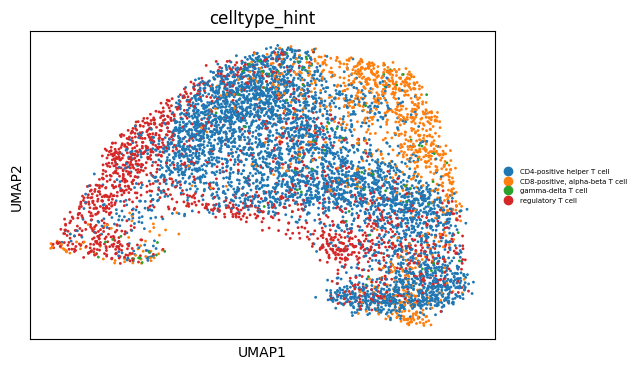

In [14]:
target_celltypes = [
'CD4-positive helper T cell',
'CD8-positive, alpha-beta T cell',
'gamma-delta T cell',
'regulatory T cell'
]

ca.safelist_celltypes(target_celltypes)
adams = ca.annotate_dataset(adams)
sc.pl.umap(adams,color="celltype_hint",legend_fontsize=5)

In [ ]:
#save annotated object
adams.write('../data/scimilarity_annotation.h5ad')

## Scirpy clonality analysis

In [26]:
import scirpy as ir
import scanpy as sc
import numpy as np
import scanpy.external as sce
import pandas as pd

Loading annotated object and subsetting to CD4 T cells only

In [3]:
adams = sc.read_h5ad('../data/scimilarity_annotation.h5ad')
np.bool = np.bool_
#restricting adata to CD4+ T cells only
cd4_ad = adams[adams.obs['celltype_hint'].isin(['CD4-positive helper T cell','regulatory T cell'])]
cd4_ad = adams[~adams.obs['prediction'].isin(['CD8 Effector IFNg hi','CD8 Effector IFNg low','γδ T cells'])]

In [4]:
#renaming ECZ6 to MGH117
cd4_ad.obs['ind_id']=np.where(cd4_ad.obs['ind_id']=='ECZ_6','MGH117',cd4_ad.obs['ind_id'])
cd4_ad.obs['ind_id'].unique()

/tmp/ipykernel_4793/1741619725.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  cd4_ad.obs['ind_id']=np.where(cd4_ad.obs['ind_id']=='ECZ_6','MGH117',cd4_ad.obs['ind_id'])


array(['ECZ_1', 'ECZ_3', 'ECZ_4', 'ECZ_5', 'MGH117', 'ECZ_MGH114',
       'MGH105', 'MGH106'], dtype=object)

/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


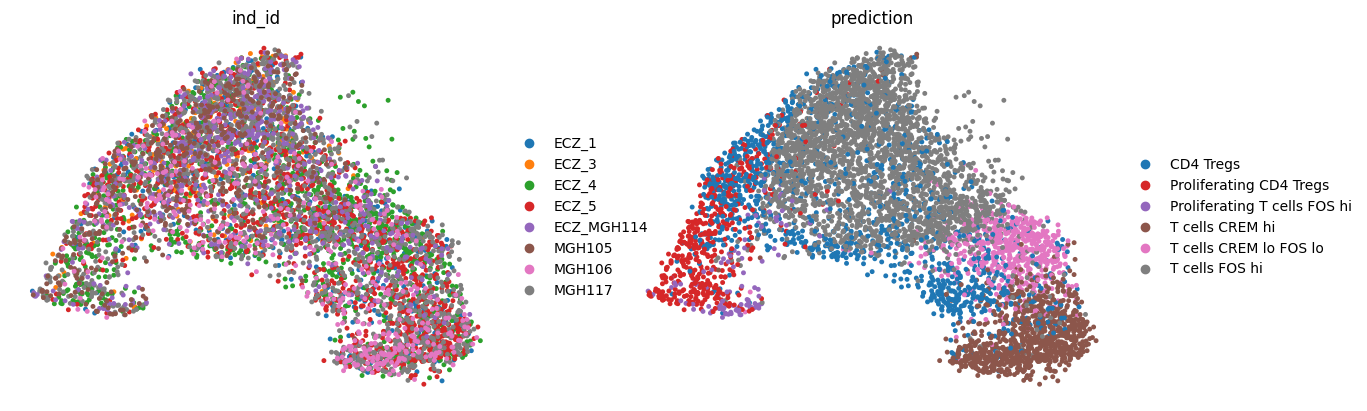

In [5]:
sc.pl.umap(cd4_ad, color=['ind_id','prediction'],frameon=False, cmap='RdBu_r', vmin=-2, vmax=2, ncols=5, size=50)

Running clonotype analysis based on AA VDJ similarity

In [6]:
ir.tl.chain_qc(cd4_ad)
#finding distance between IR sequences to assess clonality
ir.pp.ir_dist(cd4_ad, sequence='aa')

In [7]:
ir.tl.define_clonotypes(cd4_ad, receptor_arms='any',dual_ir='primary_only')
print('done')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4819/4819 [00:02<00:00, 2377.72it/s]

done


In [8]:
ir.tl.clonotype_network(cd4_ad, min_cells=2)

2025-09-26 18:26:21,592 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-26 18:26:23,523 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-26 18:26:23,547 - harmonypy - INFO - Iteration 1 of 10
2025-09-26 18:26:24,330 - harmonypy - INFO - Iteration 2 of 10
2025-09-26 18:26:25,087 - harmonypy - INFO - Iteration 3 of 10
2025-09-26 18:26:25,855 - harmonypy - INFO - Iteration 4 of 10
2025-09-26 18:26:26,611 - harmonypy - INFO - Iteration 5 of 10
2025-09-26 18:26:27,365 - harmonypy - INFO - Iteration 6 of 10
2025-09-26 18:26:28,195 - harmonypy - INFO - Iteration 7 of 10
2025-09-26 18:26:29,124 - harmonypy - INFO - Iteration 8 of 10
2025-09-26 18:26:30,070 - harmonypy - INFO - Iteration 9 of 10
2025-09-26 18:26:30,974 - harmonypy - INFO - Converged after 9 iterations
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 

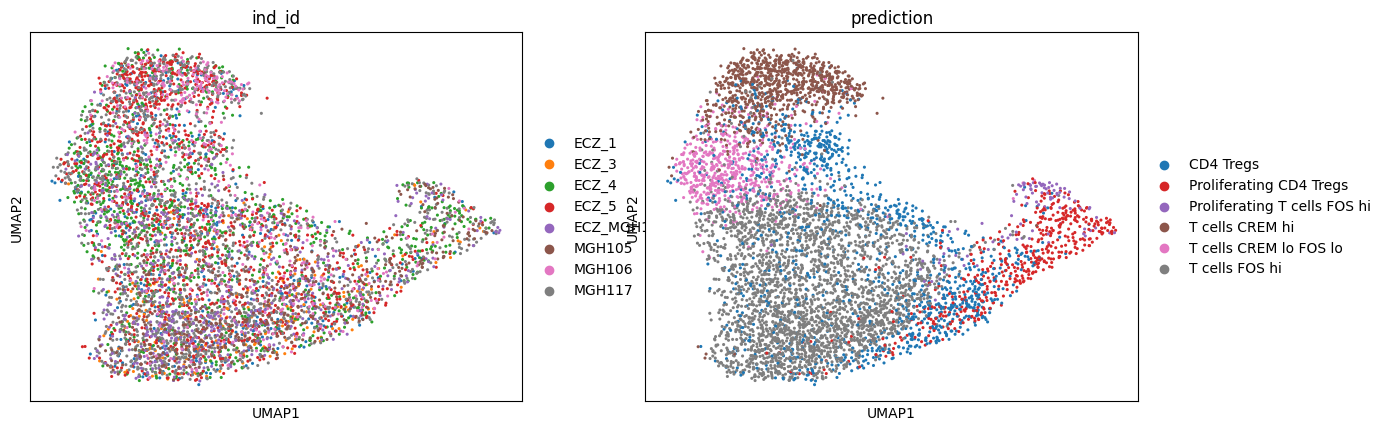

In [9]:
sc.pp.pca(cd4_ad)
sce.pp.harmony_integrate(cd4_ad, key='batch', basis='X_pca')
# Use the harmonized embedding for downstream analysis:
sc.pp.neighbors(cd4_ad, use_rep="X_harmony")
sc.tl.umap(cd4_ad)
sc.pl.umap(cd4_ad,color=['ind_id','prediction'])

/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


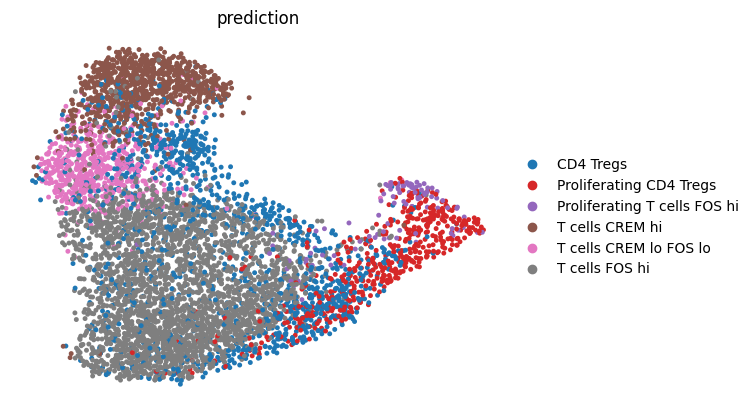

In [10]:
sc.pl.umap(cd4_ad, color=['prediction'],frameon=False, cmap='RdBu_r', vmin=-2, vmax=2, ncols=5, size=50,save='_cd4_gokcen.pdf')

In [11]:
cd4_ad.layers['scaled'] = cd4_ad.layers['counts']  # or 'counts' / 'log1p' / etc.
sc.pp.scale(cd4_ad, max_value=10, layer='scaled', copy=False)  # now scaling happens in-place on the 'scaled' layer
print(cd4_ad.layers.keys())


KeysView(Layers with keys: counts, scaled)


Looking at gene expression of IL13/IL22/IL26 enriched CD4 T cell population in TCR data

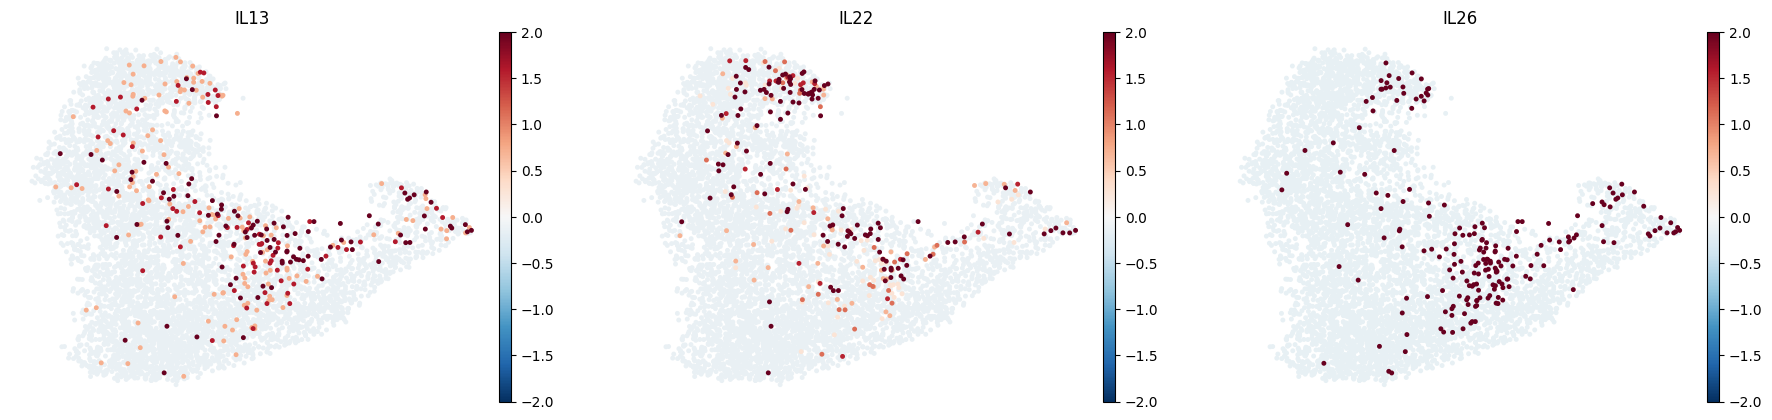

In [12]:
sc.pp.scale(cd4_ad, max_value=10, layer='scaled')
sc.pl.umap(cd4_ad, color=['IL13', 'IL22', 'IL26'],frameon=False, cmap='RdBu_r', vmin=-2, vmax=2, ncols=5, size=50,layer='scaled',save='_IL13IL22IL26_cd4.pdf')

Looking at marker gene expression for scimilarity annotations

/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


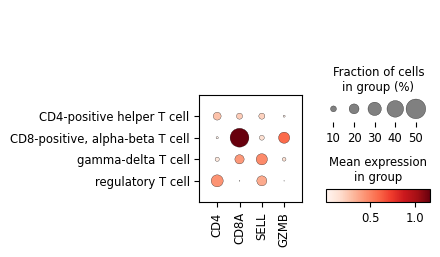

In [13]:
sc.pl.dotplot(adams,['CD4','CD8A','SELL','GZMB'],'celltype_hint')

Assessing Topic 190 gene expression in UMAP

Genes used for scoring: 23


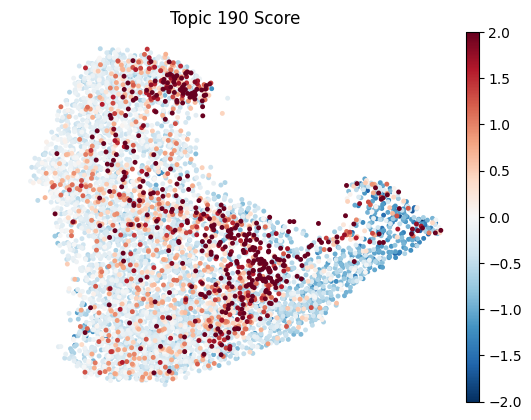

In [14]:
#topic190 expression
import numpy as np
import scanpy as sc
topic190_genes = ['NBAS',
                    'IL13',
                    'IL22',
                    'IL26',
                    'TBXAS1',
                    'IL17RB',
                    'PPARG',
                    'BCAT1',
                    'DMD',
                    'PTGDR2',
                    'PTHLH',
                    'IL9R',
                    'CHDH',
                    'HPGDS',
                    'RIMS2',
                    'ARMC12',
                    'HTR2B',
                    'IL5',
                    'CRMP1',
                    'IL31',
                    'IL21',
                    'DRP2',
                    'LRRC43']


# Get the list of genes present in your data
common_genes = [gene for gene in topic190_genes if gene in cd4_ad.var_names]
print("Genes used for scoring:", len(common_genes))


from scipy.stats import zscore
sc.tl.score_genes(cd4_ad, topic190_genes, score_name='score190', use_raw=False)
cd4_ad.obs['score190'] = zscore(cd4_ad.obs['score190'])
sc.pl.umap(cd4_ad, color='score190', size=50, cmap='RdBu_r', vmax=2, vmin=-2, frameon=False, title='Topic 190 Score',save='_topic190.pdf')#save='tcr-topic190-score.pdf'



Assessing clonal expansion in TCR data

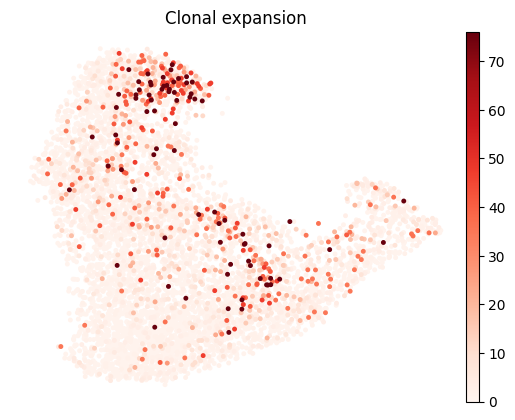

In [15]:
sc.pl.umap(cd4_ad, color='clone_id_size', size=50, frameon=False, title=['Clonal expansion'], vmin=0,cmap='Reds',save='_clonalexpansion_cd4.pdf')#, save='-clone-customgradient.pdf'

/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


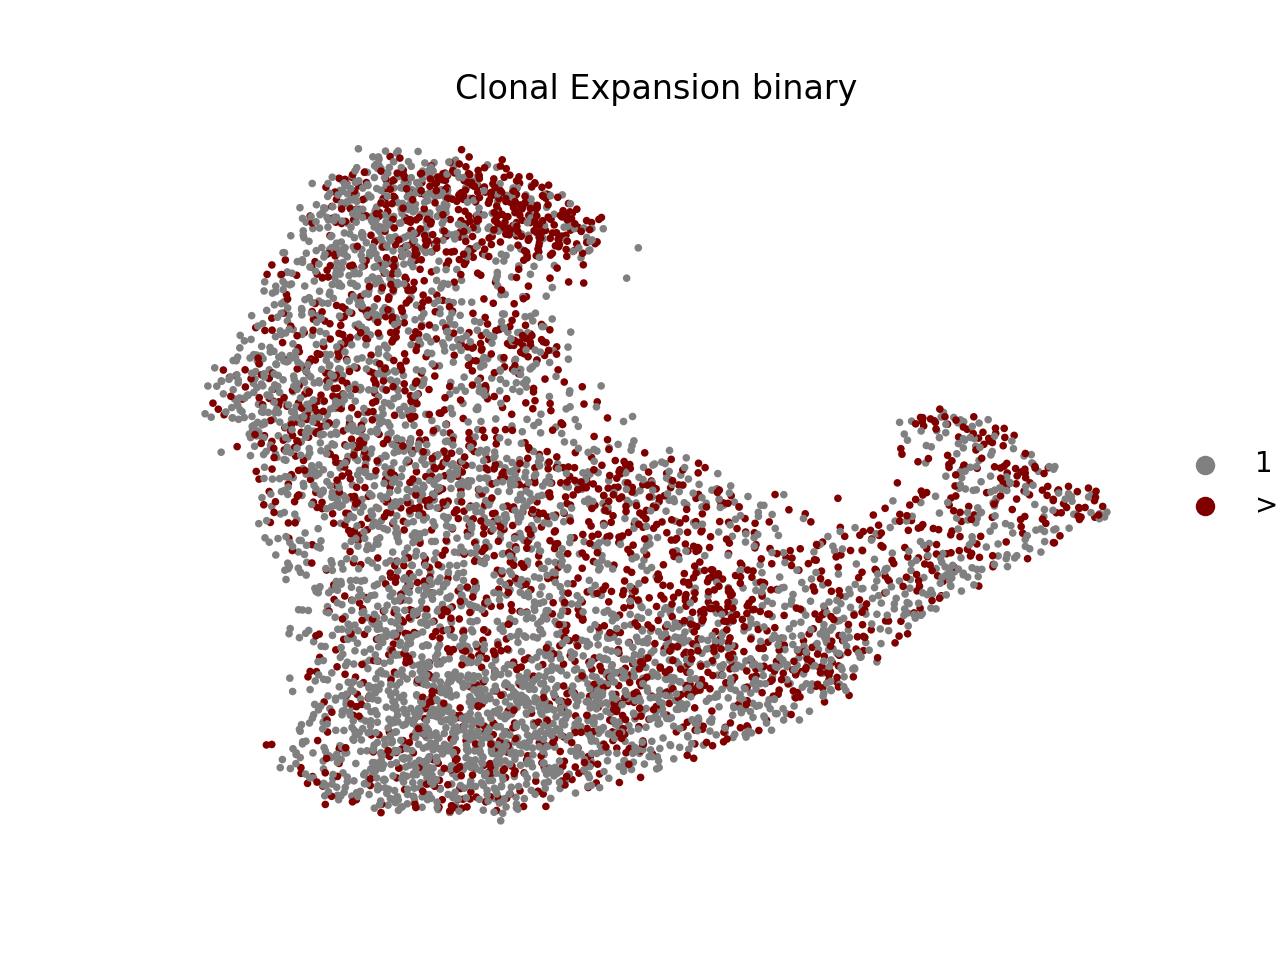

In [34]:
import pandas as pd
cd4_ad.obs['clone_binary']=np.where(cd4_ad.obs['clone_id_size'] >= 2, '>=2', '1')
cd4_ad.obs['clone_binary'] = cd4_ad.obs['clone_binary'].astype(str)
cd4_ad.obs['clone_binary'] = pd.Categorical(cd4_ad.obs['clone_binary'], categories=['1', '>=2'], ordered=True)
custom_palette = ['grey', 'maroon']
sc.pl.umap(cd4_ad, color='clone_binary', palette=custom_palette, frameon=False,size=30,title=['Clonal Expansion binary'],save='_binary_clonalexpansion.pdf')


In [17]:
cd4_ad.obs['clone_binary'].value_counts()


1      3753
>=2    2294
Name: clone_binary, dtype: int64

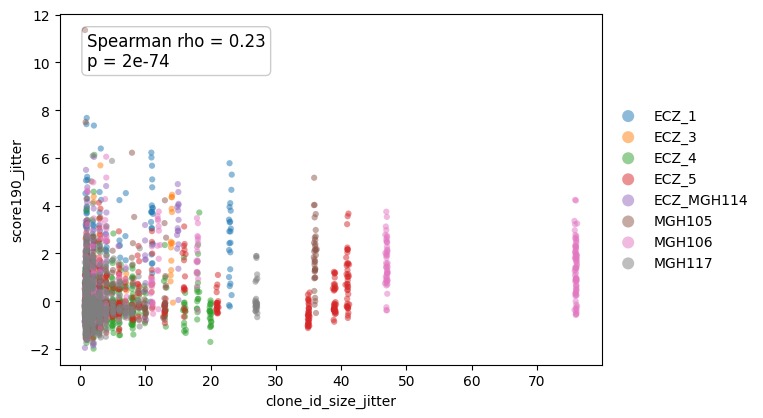

In [18]:
#scattter plot
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
ad=cd4_ad
# Add jitter to avoid overplotting
ad.obs['score190_jitter'] = ad.obs['score190'] + np.random.normal(0, 0.1, size=ad.obs.shape[0])
ad.obs['clone_id_size_jitter'] = ad.obs['clone_id_size'] + np.random.normal(0, 0.1, size=ad.obs.shape[0])

# Create the scatter plot, coloring points by 'ind_id' and including a legend
sc.pl.scatter(cd4_ad, 
              y='score190_jitter', 
              x='clone_id_size_jitter', 
              color='ind_id',         # Color by ind_id
              legend_loc='right margin',  # Legend displayed on the right
              show=False, 
              title='', 
              size=80,
              alpha=0.5)

# Compute the Spearman correlation between score190 and clone_id_size
rho, pval = spearmanr(cd4_ad.obs['clone_id_size'], cd4_ad.obs['score190'])
corr_text = f"Spearman rho = {rho:.2f}\np = {pval:.2g}"

# Annotate the current axes with the correlation text
ax = plt.gca()
ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.show()



In [19]:
import numpy as np
cd4_ad.obs['clone_binary']=np.where(cd4_ad.obs['clone_id_size'] >= 2, '>=2', '1')

In [20]:
clone_patient_pseudobulk = clone_pseudobulk.groupby(['ind_id','clone_binary']).mean()
clone_patient_pseudobulk[['score190']]

NameError: name 'clone_pseudobulk' is not defined

Looking at proportions of IL13 IL22 IL26 +ve T cells

In [21]:
genes = ['IL13', 'IL22', 'IL26']

for gene in genes:
    ad.obs[f'{gene}+'] = ['Expressed' if x>0 else 'Not expressed' for x in ad.obs_vector(gene)]
    
ad.obs['IL22/IL26'] = [f'IL22{"+" if x else "-"}IL26{"+" if y else "-"}' for x,y in zip(ad.obs_vector('IL22')>0, ad.obs_vector('IL26')>0)]
ad.obs['IL13/IL26'] = [f'IL13{"+" if x else "-"}IL26{"+" if y else "-"}' for x,y in zip(ad.obs_vector('IL13')>0, ad.obs_vector('IL26')>0)]
ad.obs['IL13/IL22'] = [f'IL13{"+" if x else "-"}IL22{"+" if y else "-"}' for x,y in zip(ad.obs_vector('IL13')>0, ad.obs_vector('IL22')>0)]

ad._sanitize()

ad.uns['IL22/IL26_colors'] = ['purple', '#DA3C3D', '#3584BB', 'darkgrey']
ad.uns['IL13/IL26_colors'] = ['purple', '#DA3C3D', '#3584BB', 'darkgrey']
ad.uns['IL13/IL22_colors'] = ['purple', '#DA3C3D', '#3584BB', 'darkgrey']


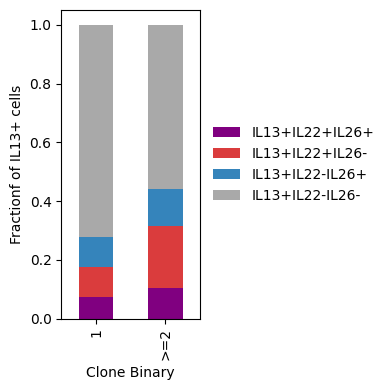

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assume ad is your AnnData object and has been subset to IL13+ cells:
# For example:
ad_subset = ad[ad.obs_vector('IL13') > 0].copy()
# We'll use its .obs DataFrame.
df = ad_subset.obs.copy()

# Ensure that clone_binary is a column (reset index if needed) and is a string.
if 'clone_binary' not in df.columns and 'clone_binary' in df.index.names:
    df = df.reset_index()
df['clone_binary'] = df['clone_binary'].astype(str)

# We'll use the 'IL22/IL26' column as our categorical variable for the stacked bar.
# Ensure it is a string (if not already).
df['IL22/IL26'] = df['IL22/IL26'].astype(str)

# Group by clone_binary and IL22/IL26 to count cells in each combination.
grouped = df.groupby(['clone_binary', 'IL22/IL26']).size().reset_index(name='count')

# Compute proportions within each clone_binary group.
grouped['proportion'] = grouped.groupby('clone_binary')['count'].transform(lambda x: x / x.sum())

# Pivot the table so that each clone_binary is a row and the IL22/IL26 categories are columns.
pivot = grouped.pivot(index='clone_binary', columns='IL22/IL26', values='proportion').fillna(0)

# Optionally, specify the order of the IL22/IL26 categories.
# Here is an example order. Adjust if your actual category strings differ.
desired_order = ["IL22+IL26+", "IL22+IL26-", "IL22-IL26+", "IL22-IL26-"]
# Reindex the columns (if some categories are missing, they will be ignored).
pivot = pivot.reindex(columns=desired_order)

# Get the color palette from ad.uns if defined; otherwise use a default.
colors = ad.uns.get('IL22/IL26_colors', sns.color_palette('pastel', n_colors=4))

# Create the stacked bar plot.
ax = pivot.plot(kind='bar', stacked=True, color=colors, figsize=(4,4))
ax.set_xlabel("Clone Binary")
ax.set_ylabel("Fractionf of IL13+ cells")

# Reassign legend labels. For example, if you want to rename the categories:
new_labels = ["IL13+IL22+IL26+", "IL13+IL22+IL26-", "IL13+IL22-IL26+", "IL13+IL22-IL26-"]

# Get handles (patches) and assign new labels.
handles, _ = ax.get_legend_handles_labels()
# Create a new legend, move it to the right side, and remove the frame.
ax.legend(handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.savefig('figures/stackedbarplot_clonebinary_il13il22il26proportion.pdf', format='pdf', bbox_inches='tight')
plt.show()

DE analysis of clonally expanded T cells

In [27]:
# Ensure you have computed rank_genes_groups:
if "rank_genes_groups" not in cd4_ad.uns:
    sc.tl.rank_genes_groups(cd4_ad, groupby='clone_binary', method='t-test')

# Now get the dataframe
df = sc.get.rank_genes_groups_df(cd4_ad, group='>=2')

# Define gene lists
il13_genes = ['NBAS', 'IL13', 'IL22', 'IL26', 'TBXAS1', 'IL17RB', 'PPARG', 'BCAT1',
              'DMD', 'PTGDR2', 'PTHLH', 'IL9R', 'CHDH', 'HPGDS', 'RIMS2', 'ARMC12',
              'HTR2B', 'IL5', 'CRMP1', 'IL31', 'IL21', 'DRP2', 'LRRC43']

highlights = ['IL22', 'IL13', 'IL26', 'IL9R', 'CD7', 'GZMB', 'GZMK', 'KLRG1', 'CD27',
              'FOXP3', 'HLA-DRA', 'HLA-DRB1', 'IL4', 'IL5', 'IL17RB', 'PPARG', 'PTHLH',
              'HPGDS', 'IL31', 'NBAS', 'SELL', 'LAIR1', 'LGALS1', 'PTGDR2', 'CHDH',
              'HPGDS', 'LGALS3'] + il13_genes

# Add new columns
df['neglogpval'] = -np.log10(df.pvals_adj)
df['significant'] = (df.pvals_adj < 0.1) & (df.logfoldchanges.abs() > 0.5)
df['highlight'] = df.names.isin(highlights)


In [28]:
df['group']=np.where(df['logfoldchanges']>0,'Expanded (n>=2)','Non-expanded (n=1)')
df[['group','names','scores','logfoldchanges','pvals','pvals_adj']].to_excel('../data/supp_table_12.xlsx', index=False)

/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 4 in image.
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: figures/tcr-volcano_clone_binary.pdf
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1407 rows containing missing values.
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 9 rows containing missing values.
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/home/tjain/miniconda3/envs/scirpy-env/lib/python3.8/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1407 rows containing missing values.
/home/tjain/miniconda3/envs/scirpy-en

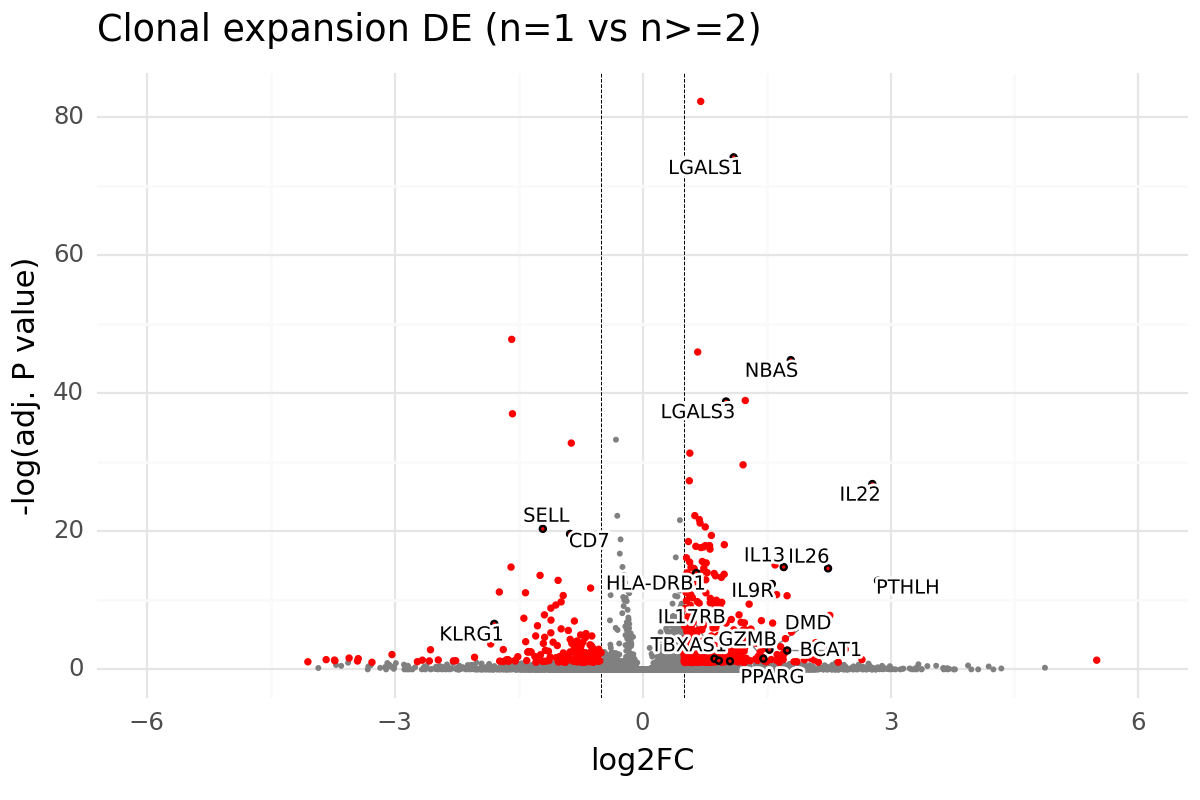

<Figure Size: (600 x 400)>

In [29]:
import matplotlib.patheffects as path_effects
import plotnine as p9

f = (
    p9.ggplot(df, p9.aes(x='logfoldchanges', y='neglogpval')) + 
    p9.geom_vline(xintercept=0.5, size=0.2, linetype='dashed') +
    p9.geom_vline(xintercept=-0.5, size=0.2, linetype='dashed') +    
    p9.geom_point(size=0.2, color='gray', data=df[~df.significant]) + 
    p9.geom_point(size=0.5, color='red', data=df[df.significant]) +
    p9.geom_point(size=0.7, fill='red', color='black', data=df[df.highlight & (df.significant)]) +         
    p9.geom_text(p9.aes(label='names'),
                 data=df[df.highlight & (df.significant)],
                 size=7,
                 adjust_text={
                     'x': df[df.highlight].logfoldchanges.values,
                     'y': df[df.highlight].neglogpval.values,
                     'expand_points': (1.5, 1.5), 
                     'arrowprops': {'arrowstyle': '-', 'color': 'gray', 'lw': 0.5}
                 },
                 path_effects=[
                     path_effects.Stroke(linewidth=2, foreground='white'),
                     path_effects.Normal()
                 ]) +
    p9.theme_minimal() + 
    p9.labs(x='log2FC', y='-log(adj. P value)', title='Clonal expansion DE (n=1 vs n>=2)') + 
    p9.theme(figure_size=(6,4)) +
    p9.lims(x=(-6,6))
)

p9.ggsave(f, 'figures/tcr-volcano_clone_binary.pdf')
f


In [37]:
#save h5ad obj
cd4_ad.write_h5ad('../data/03282025_TCR_CD4.h5ad')

## ED Figures m,o,p,q

In [6]:
cd4_ad.obs['ind_id']=np.where(cd4_ad.obs['ind_id']=='ECZ_6','MGH117',cd4_ad.obs['ind_id'])

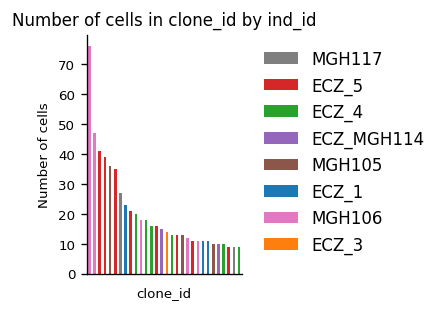

In [7]:
import matplotlib.pyplot as plt

# Create your plot (using ir.pl.group_abundance)
ax = ir.pl.group_abundance(cd4_ad, groupby='clone_id', max_cols=30, target_col='ind_id')
ax.set_xticklabels([])

# Remove any existing legend if present
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Create a new legend and place it outside (to the right) of the axes.
leg = ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

# Adjust the layout so that the axes don't expand into the legend area.
fig = ax.get_figure()
fig.subplots_adjust(right=0.5)  # You can increase this value if needed
plt.savefig('../figs/barplot_TCR_top30clones_ED.pdf')
plt.show()


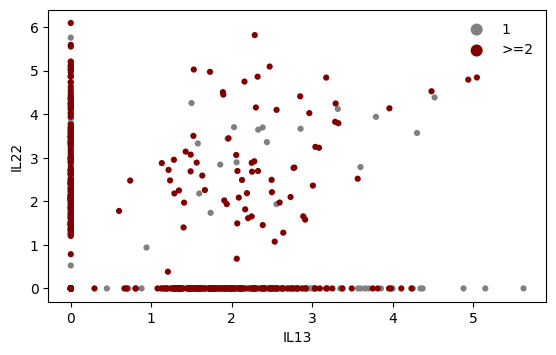

In [8]:
import scanpy as sc
import matplotlib.pyplot as plt

# Option 1: Set the default figure size in Scanpy:
sc.settings.figsize = (4,4)  # width, height in inches
sc.pl.scatter(cd4_ad, 'IL13', 'IL22', color='clone_binary', 
              legend_loc='upper right', show=True, title='', size=80,
              save='_TCR_IL22_vs_IL13.pdf')


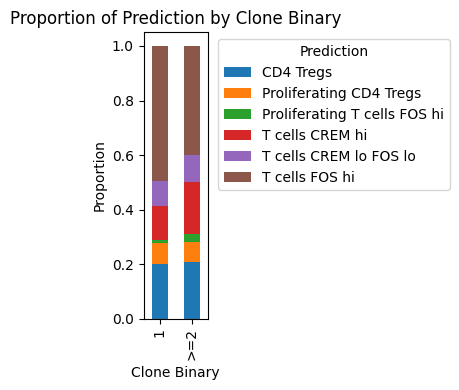

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the obs DataFrame; reset index if needed so that clone_binary is a column.
df = cd4_ad.obs.copy()
if 'clone_binary' in df.index.names:
    df = df.reset_index()

# Ensure that the columns are strings (or categorical) so they are treated as discrete groups.
df['clone_binary'] = df['clone_binary'].astype(str)
df['prediction'] = df['prediction'].astype(str)

# Group by clone_binary and prediction to count the number of cells in each combination.
grouped = df.groupby(['clone_binary', 'prediction']).size().reset_index(name='count')

# Compute proportions within each clone_binary group.
grouped['proportion'] = grouped.groupby('clone_binary')['count'].transform(lambda x: x / x.sum())

# Pivot the table so that each row is a clone_binary group and columns are prediction categories.
pivot = grouped.pivot(index='clone_binary', columns='prediction', values='proportion').fillna(0)

# Optionally, define a desired order for prediction categories (if needed)
# For example, if you know the categories, you can do:
# desired_order = ['PredictionA', 'PredictionB', 'PredictionC']
# pivot = pivot.reindex(columns=desired_order)

# Create the stacked barplot.
ax = pivot.plot(kind='bar', stacked=True, figsize=(4,4))

ax.set_xlabel('Clone Binary')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Prediction by Clone Binary')

# Adjust legend: place it to the right
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Prediction', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figs/stackedbarplot_TCR_CD4_celltype_by_clonebinary_ED.pdf')
plt.show()


In [60]:
genes = ['IFNG', 'IL13', 'IL22', 'IL26']

for gene in genes:
    cd4_ad.obs[f'{gene}+B'] = cd4_ad.obs_vector(gene)>0
    cd4_ad.uns[f'{gene}+B_colors'] = ['#B42728', '#DDDDDD']

Pseudobulking topic 190 scores to a patient level to compare score difference between clonally expanded vs non-clonally expanded T cells

In [49]:
patient_pseudobulk = (
    cd4_ad.obs
      .groupby(['ind_id', 'clone_binary'])['score190']
      .mean()
      .reset_index(name='score190')
)


In [50]:
df = patient_pseudobulk

In [51]:
df['clone_binary']=np.where(df['clone_binary']=='>=2','2',df['clone_binary'])

Significant combinations: [[(1, 2), 0.014607538879281639]]


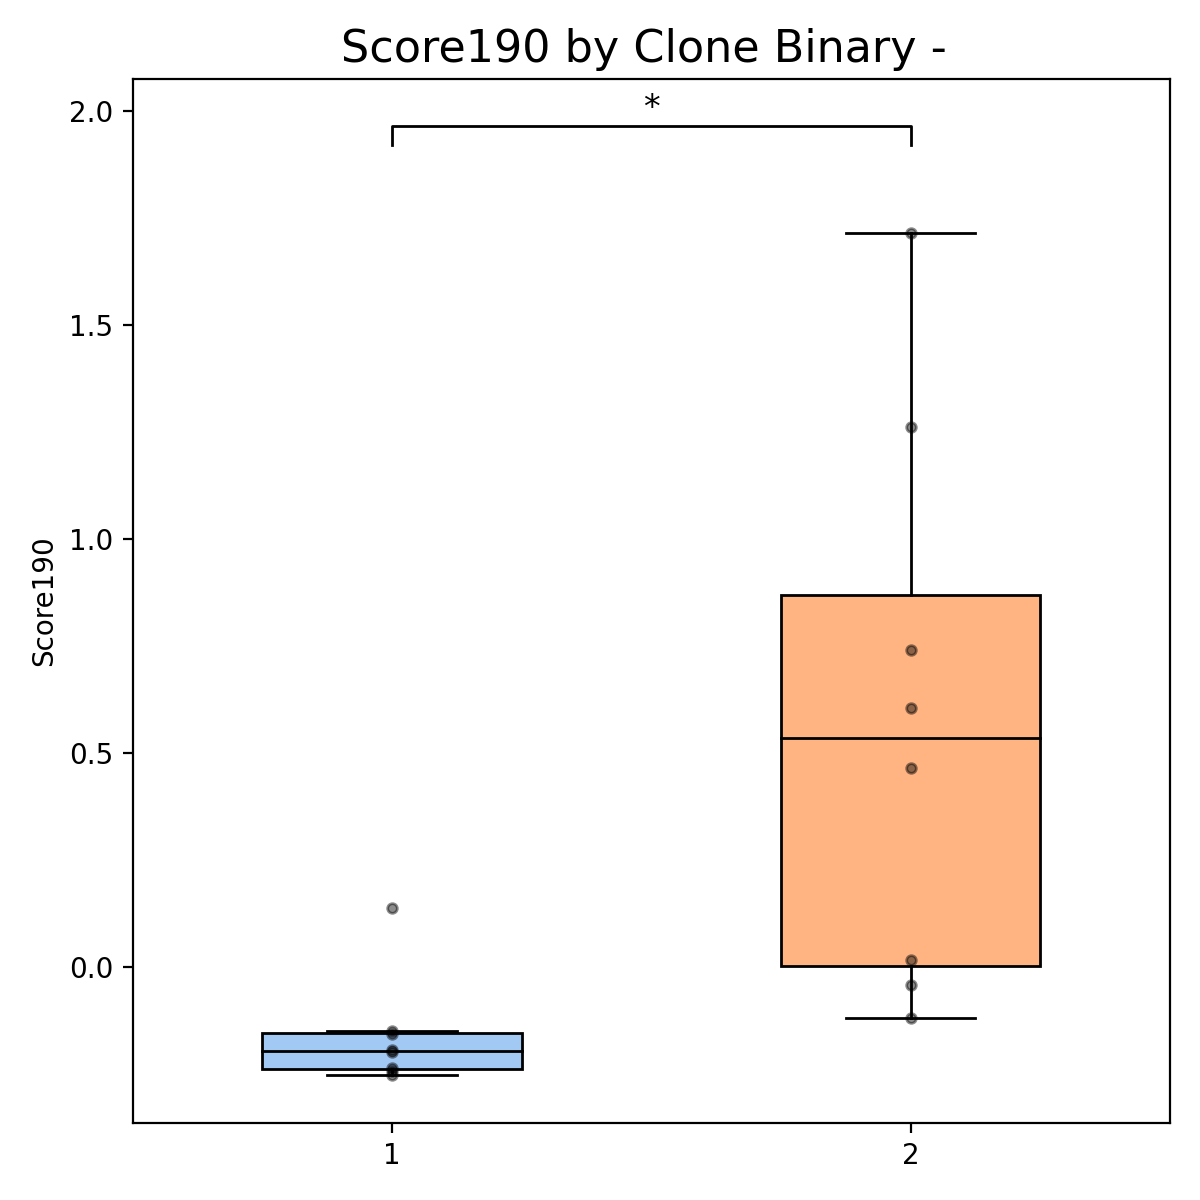

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd

# Assume df already exists (patient_pseudobulk copy)
# If you actually need it: df = patient_pseudobulk.copy()
if 'clone_binary' in df.index.names:
    df = df.reset_index()

# Ensure clone_binary is a string (categorical)
df['clone_binary'] = df['clone_binary'].astype(str)

# Sort groups by numeric order (if appropriate)
groups = sorted(df['clone_binary'].unique(), key=lambda x: float(x))

# Prepare data: for each group, extract the 'score190' values
data = [df[df['clone_binary'] == g]['score190'].values for g in groups]

# Compute significance tests for all pairs using a t-test (Welch)
significant_combinations = []
ls = list(range(1, len(data) + 1))
combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
for combination in combinations:
    data1 = data[combination[0] - 1]
    data2 = data[combination[1] - 1]
    t_stat, p = stats.ttest_ind(data1, data2, equal_var=False)
    if p < 0.05:
        significant_combinations.append([combination, p])

print("Significant combinations:", significant_combinations)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# Boxplot
bp = ax.boxplot(
    data, widths=0.5, patch_artist=True, labels=groups, showfliers=False
)

# Colors
colors = sns.color_palette('pastel', len(data))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.setp(bp['medians'], color='k')

ax.set_title('Score190 by Clone Binary - ', fontsize=16)
ax.set_ylabel('Score190')

# ===== Add jittered data points (one layer per group) =====
rng = np.random.default_rng(0)  # fixed seed for reproducible jitter
x_positions = np.arange(1, len(groups) + 1)  # box centers are 1..N

for xi, g in zip(x_positions, groups):
    y = df.loc[df['clone_binary'].eq(g), 'score190'].values
    # small random horizontal jitter around the box center
    x = xi + rng.uniform(0,0, size=len(y))
    ax.scatter(x, y, s=12, c='k', alpha=0.45, zorder=3)

# ===== Recompute limits AFTER adding dots =====
bottom, top = ax.get_ylim()
y_range = top - bottom

# ===== Significance bars =====
for i, sig in enumerate(significant_combinations):
    (x1, x2), p = sig
    level = len(significant_combinations) - i
    bar_height = top + y_range * 0.07 * level
    bar_tips = bar_height - y_range * 0.02
    ax.plot([x1, x1, x2, x2], [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')

    if p < 0.001:
        sig_symbol = '***'
    elif p < 0.01:
        sig_symbol = '**'
    elif p < 0.05:
        sig_symbol = '*'
    else:
        sig_symbol = 'ns'

    ax.text((x1 + x2) / 2, bar_height + y_range * 0.001, sig_symbol,
            ha='center', va='bottom', color='k', fontsize=12)

plt.tight_layout()
plt.show()
